GOOD FIT:


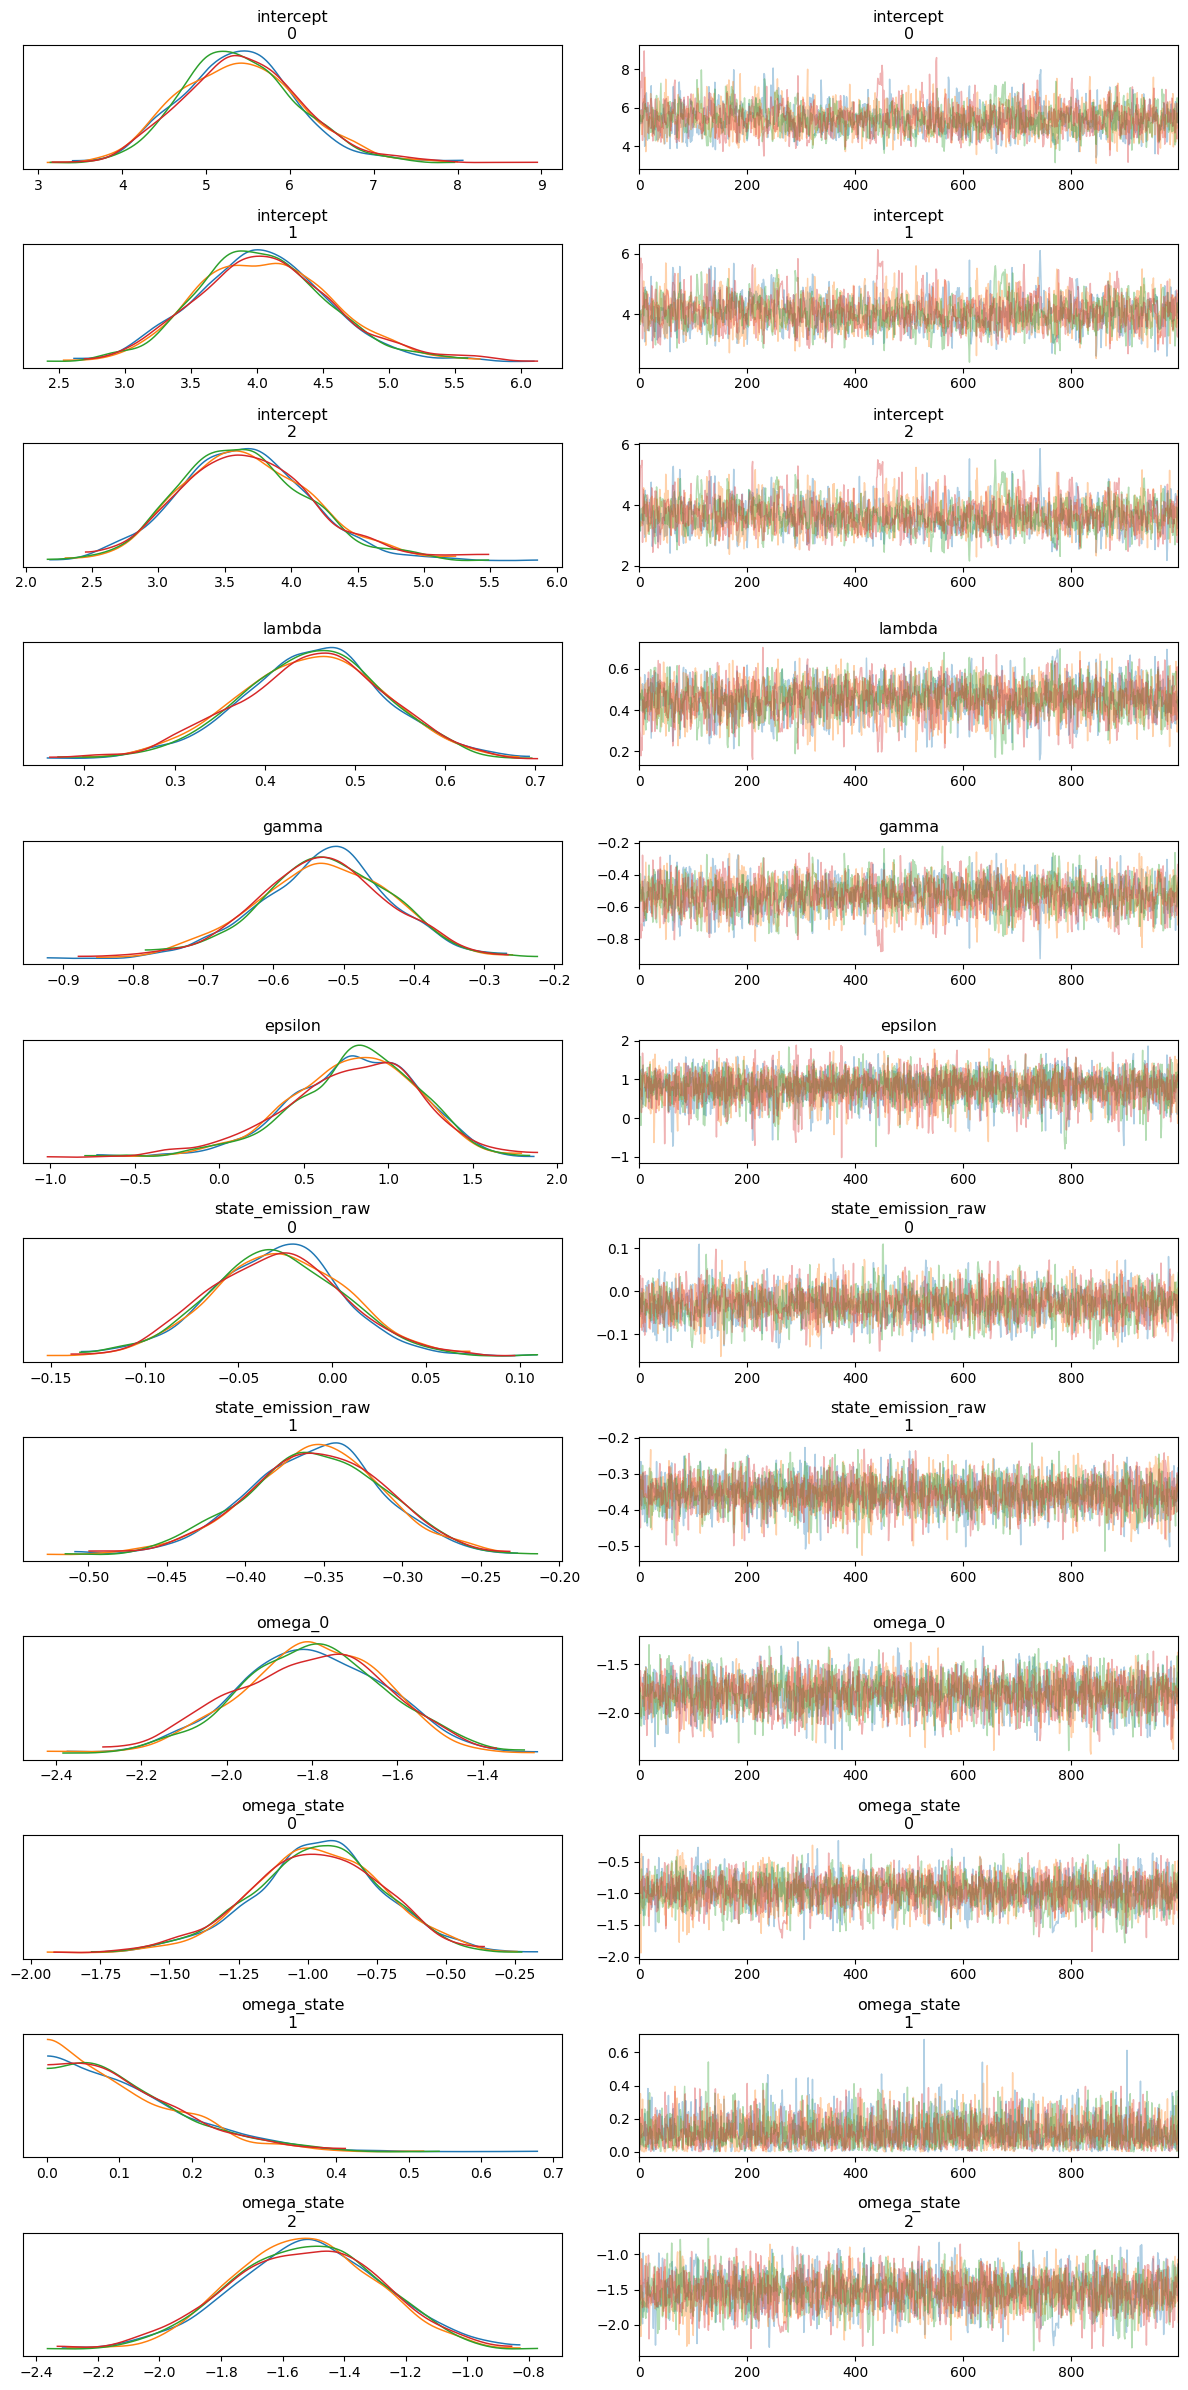

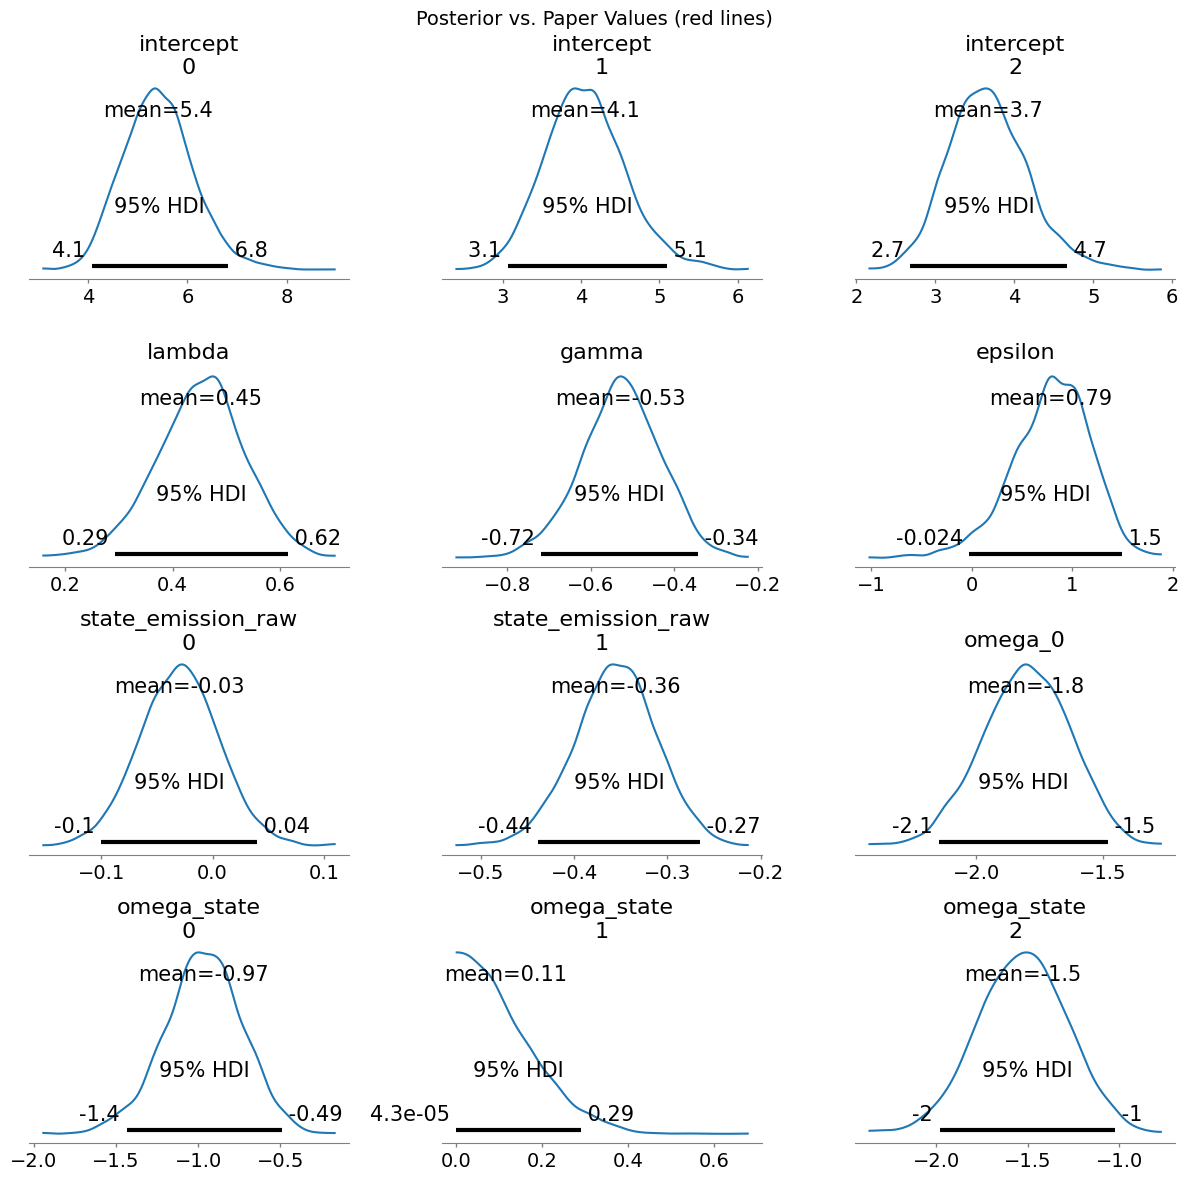

In [3]:
from constants import FITTED_MODEL_FOLDER_2000_ITER
from helpers import load_fitted_model
import arviz as az
import matplotlib.pyplot as plt

az.rcParams["stats.ci_prob"] = 0.95  # set CI to 95%

# Lade funktionierende Modelle
good_vdhmm3 = load_fitted_model("vdhmm", S=3)
bad_vdhmm4 = load_fitted_model("vdhmm", S=4)

# Vergleiche state_emission Posterior
good_summary = good_vdhmm3.summary
bad_summary = bad_vdhmm4.summary

# print("VDHMM S=3 (gut):")
# print(good_summary[good_summary.index.str.contains("state_emission")])

# print("\nVDHMM S=4 (schlecht):")
# print(bad_summary[bad_summary.index.str.contains("state_emission")])

fit = bad_vdhmm4.fit

for idx, fit in enumerate([good_vdhmm3.fit]):
    print("=" * 60)
    print("GOOD FIT:" if idx == 0 else "BAD FIT:")
    print("=" * 60)
    # Konvertiere zu ArviZ InferenceData
    inference_data = az.from_cmdstanpy(fit)

    # Trace Plot für problematische Parameter
    az.plot_trace(
        inference_data,
        var_names=[
            "intercept",
            "lambda",
            "gamma",
            "epsilon",
            "state_emission_raw",
            "omega_0",
            "omega_state",
        ],
        compact=False,
    )
    plt.tight_layout()
    plt.show()

    az.plot_posterior(
        inference_data,
        var_names=[
            "intercept",
            "lambda",
            "gamma",
            "epsilon",
            "state_emission_raw",
            "omega_0",
            "omega_state",
        ],
        figsize=(12, 12),
    )
    plt.suptitle("Posterior vs. Paper Values (red lines)", fontsize=14)
    plt.tight_layout()
    plt.show()

    # # State emissions (wichtig für Label Switching)
    # az.plot_trace(inference_data, var_names=["state_emission"])
    # plt.show()

    # # Omega states
    # az.plot_trace(inference_data, var_names=["omega_state_raw", "omega_state_mid"])
    # plt.show()

In [4]:
# ============================================================================
# PARAMETER-VERGLEICH MIT NAUMZIK ET AL. (2022) PAPER
# ============================================================================

print("=" * 80)
print("DIAGNOSE: VERGLEICH MIT PAPER (Naumzik et al., 2022)")
print("=" * 80)

# Paper-Werte aus Table 4 (Seite 199)
paper_values = {
    "intercept": -1.8205,
    "omega_state[1]": -0.3239,  # Well-running state
    "omega_state[2]": 0.8862,  # At-risk state
    "omega_state[3]": 0.2559,  # Bad-ratings-but-running state
}

print("\n1. STATE-FAILURE EMISSION COMPONENT (ω-Parameter)")
print("-" * 80)

# Vergleichstabelle
print(
    f"{'Parameter':<40} | {'Ihre Werte':>12} | {'Paper':>12} | {'Differenz':>12} | Status"
)
print("-" * 95)

# Intercept
if "omega_0" in good_summary.index:
    your_intercept = good_summary.loc["omega_0", "Mean"]
    paper_intercept = paper_values["intercept"]
    diff_intercept = your_intercept - paper_intercept
    status = "✓" if abs(diff_intercept) < 0.2 else "✗"
    print(
        f"{'Intercept (ω₀)':<40} | {your_intercept:>12.4f} | {paper_intercept:>12.4f} | {diff_intercept:>+12.4f} | {status}"
    )

print()

# Latent State Durations
for i in range(1, 4):
    param_name = f"omega_state[{i}]"
    if param_name in good_summary.index:
        your_val = good_summary.loc[param_name, "Mean"]
        paper_val = paper_values[param_name]
        diff = your_val - paper_val
        status = "✓" if abs(diff) < 0.5 else "✗✗" if abs(diff) > 1.5 else "✗"

        state_names = {
            1: "Well-running state (ω₁)",
            2: "At-risk state (ω₂)",
            3: "Bad-ratings-but-running (ω₃)",
        }

        print(
            f"{state_names[i]:<40} | {your_val:>12.4f} | {paper_val:>12.4f} | {diff:>+12.4f} | {status}"
        )

# Zusätzliche Parameter (nicht im Paper berichtet)
print("\n\n2. VARIABLE-DURATION TRANSITION COMPONENT")
print("-" * 80)
print(f"{'Parameter':<40} | {'Ihre Werte':>12} | {'Interpretation'}")
print("-" * 80)

transition_params = {
    "lambda": ("λ₁: State duration effect", "Duration dependency"),
    "gamma": ("λ₂: Time between ratings", "Calendar time effect"),
    "epsilon": ("λ₃: Review sentiment", "Sentiment effect"),
}

for param, (name, interpretation) in transition_params.items():
    if param in good_summary.index:
        val = good_summary.loc[param, "Mean"]
        print(f"{name:<40} | {val:>12.4f} | {interpretation}")

# State Emission Intercepts
print("\n\n3. STATE-RATING EMISSION (Intercepts ηs)")
print("-" * 80)
print(f"{'State':<40} | {'Ihre Werte':>12} | {'Interpretation'}")
print("-" * 80)

for i in range(1, 4):
    param_name = f"intercept[{i}]"
    if param_name in good_summary.index:
        val = good_summary.loc[param_name, "Mean"]
        print(
            f"{f'State {i} (η{i})':<40} | {val:>12.4f} | Higher = more positive ratings"
        )

# State Emissions Analyse
print("\n\n4. STATE-SPECIFIC RATING DISTRIBUTIONS")
print("-" * 80)
print(
    "\nAnalyse der state_emission Parameter (zur Identifikation von Label Switching):"
)
print()

emission_summary = good_summary[good_summary.index.str.contains("state_emission\[")]
if not emission_summary.empty:
    # Gruppiere nach States
    for state in range(1, 4):
        print(f"\nState {state}:")
        state_emissions = emission_summary[
            emission_summary.index.str.contains(f"state_emission\[{state},")
        ]

        if not state_emissions.empty:
            # Zeige Verteilung über Rating-Werte (1-5 Sterne)
            print(f"{'  Rating':<10} | {'Wahrscheinlichkeit':>20}")
            print("  " + "-" * 35)
            for rating in range(1, 6):
                param = f"state_emission[{state},{rating}]"
                if param in emission_summary.index:
                    prob = emission_summary.loc[param, "Mean"]
                    stars = "★" * rating + "☆" * (5 - rating)
                    print(f"  {stars:<10} | {prob:>20.4f}")

# Diagnose und Empfehlungen
print("\n\n" + "=" * 80)
print("DIAGNOSE & EMPFEHLUNGEN")
print("=" * 80)

# Berechne durchschnittliche Abweichung
deviations = []
for i in range(1, 4):
    param_name = f"omega_state[{i}]"
    if param_name in good_summary.index:
        your_val = good_summary.loc[param_name, "Mean"]
        paper_val = paper_values[param_name]
        deviations.append(abs(your_val - paper_val))

avg_deviation = sum(deviations) / len(deviations) if deviations else 0

print(f"\nDurchschnittliche Abweichung der ω-Parameter: {avg_deviation:.4f}")
print()

if avg_deviation > 1.0:
    print("⚠️  WARNUNG: GROSSE ABWEICHUNGEN FESTGESTELLT")
    print()
    print("Mögliche Ursachen:")
    print("1. 🔄 LABEL SWITCHING: Die States könnten anders zugeordnet sein")
    print("   → Prüfen Sie die state_emission Verteilungen oben")
    print("   → Welcher State hat die meisten 5-Sterne vs. 1-Sterne Ratings?")
    print()
    print("2. 📊 UNTERSCHIEDLICHE DATEN: Verwenden Sie andere Daten als das Paper?")
    print("   → Paper: Yelp Phoenix, AZ (2010-2017), 921 Restaurants")
    print()
    print("3. 🎲 INITIALISIERUNG: Unterschiedliche Seeds oder Startwerte")
    print("   → Prüfen Sie die verwendeten Seeds und Priors")
    print()
    print("4. 💻 IMPLEMENTIERUNG: Unterschiede im Stan-Code")
    print("   → Vergleichen Sie Ihre Implementierung mit dem Paper")
    print()
    print("Nächste Schritte:")
    print("• Analysieren Sie die state_emission Wahrscheinlichkeiten (siehe oben)")
    print("• Vergleichen Sie Ihre Daten mit den Paper-Spezifikationen")
    print("• Prüfen Sie die Convergence-Diagnostics (R-hat, ESS)")
    print("• Visualisieren Sie die Trace Plots der omega_state Parameter")
elif avg_deviation > 0.5:
    print("⚡ MODERATE ABWEICHUNGEN")
    print("Die Parameter weichen moderat ab, aber die qualitativen Muster")
    print("könnten noch konsistent sein. Prüfen Sie die Vorzeichen!")
else:
    print("✅ GUTE ÜBEREINSTIMMUNG")
    print("Die Parameter stimmen gut mit dem Paper überein.")

print("\n" + "=" * 80)

DIAGNOSE: VERGLEICH MIT PAPER (Naumzik et al., 2022)

1. STATE-FAILURE EMISSION COMPONENT (ω-Parameter)
--------------------------------------------------------------------------------
Parameter                                |   Ihre Werte |        Paper |    Differenz | Status
-----------------------------------------------------------------------------------------------
Intercept (ω₀)                           |      -1.8026 |      -1.8205 |      +0.0179 | ✓

Well-running state (ω₁)                  |      -0.9680 |      -0.3239 |      -0.6441 | ✗
At-risk state (ω₂)                       |       0.1143 |       0.8862 |      -0.7719 | ✗
Bad-ratings-but-running (ω₃)             |      -1.5281 |       0.2559 |      -1.7840 | ✗✗


2. VARIABLE-DURATION TRANSITION COMPONENT
--------------------------------------------------------------------------------
Parameter                                |   Ihre Werte | Interpretation
----------------------------------------------------------------

<>:96: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:102: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:96: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:102: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
/var/folders/hc/g9ymkbv17hbdwc11nytysx7m0000gn/T/ipykernel_42479/867945837.py:96: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
  emission_summary = good_summary[good_summary.index.str.contains("state_emission\[")]
/var/folders/hc/g9ymkbv17hbdwc11nytysx7m0000gn/T/ipykernel_42479/8